# Parameter Space Landscape Comparison

This notebook compares two different parameterization strategies for quantum sensing optimization:

1. **θ, Δθ strategy**: Uses symmetric rotations Ry(θ+Δθ) and Ry(θ-Δθ)
2. **θ₁, θ₂ strategy**: Uses independent rotations Ry(θ₁) and Ry(θ₂)

We'll visualize the loss function landscapes and analyze optimization behavior for both approaches.

In [10]:
# Import required libraries
import jax
import jax.numpy as jnp
from jax import random, jit, grad, vmap
import qutip as qt
import qutip_jax as qtj
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
import optax
from functools import partial
import warnings
warnings.filterwarnings('ignore')

In [11]:
gm = 0.03 * 2 * np.pi        # photon-cavity coupling
sigma = 0.1 * gm             # inverse of the pulse width
chi = 0.5 * gm               # dispersive coupling
nlev = 2                     # Number of cavity levels
qlev = 2                     # Number of qubit levels

# Noise parameters
gamma_relax = 0.0001 * 2 * np.pi      # qubit relaxation rate
gamma_dephasing = 0.0001 * 2 * np.pi  # qubit dephasing rate 
gamma_depol = 0.000 * 2 * np.pi       # depolarizing noise rate

# Measurement configuration
tmeas = [-5.0, -2.5, 0, 2.5, 5.0]          # Measurement time points (in units of sigma)
measurements = np.array(tmeas) / sigma       # normalize by sigma

args = {'sigma': sigma}               # arguments for coefficient function

print(f"System parameters:")
print(f"  Cavity levels: {nlev}")
print(f"  Photon-cavity coupling (γ): {gm:.6f}")
print(f"  Pulse width inverse (σ): {sigma:.6f}")
print(f"  Dispersive coupling (χ): {chi:.6f}")
print(f"  Noise - Relaxation: {gamma_relax:.6f}")
print(f"  Noise - Dephasing: {gamma_dephasing:.6f}")
print(f"  Noise - Depolarizing: {gamma_depol:.6f}")
print(f"  Measurement times: {measurements}")

System parameters:
  Cavity levels: 2
  Photon-cavity coupling (γ): 0.188496
  Pulse width inverse (σ): 0.018850
  Dispersive coupling (χ): 0.094248
  Noise - Relaxation: 0.000628
  Noise - Dephasing: 0.000628
  Noise - Depolarizing: 0.000000
  Measurement times: [-265.25823849 -132.62911924    0.          132.62911924  265.25823849]


In [12]:
# Quantum operators for three-system composite space: input ⊗ resonator ⊗ qubit
with qt.CoreOptions(default_dtype="jax"):
    
    # Identity operators for each subsystem
    Iq = qt.identity(qlev)  # Qubit identity (2×2)
    In = qt.identity(nlev)  # Cavity identity (2×2)
    
    # Creation and annihilation operators for cavity modes
    An = qt.destroy(nlev)   # Cavity annihilation operator
    Acn = qt.create(nlev)   # Cavity creation operator
    
    # Pauli matrices for qubit operations
    Sz = qt.sigmaz()        # Pauli-Z matrix
    Sx = qt.sigmax()        # Pauli-X matrix
    Sy = qt.sigmay()        # Pauli-Y matrix
    Sminus = qt.destroy(qlev)  # Qubit annihilation operator
    
    # Qubit measurement projectors
    P0 = qt.Qobj([[1,0],[0,0]])  # Ground state projector |0⟩⟨0|
    P1 = qt.Qobj([[0,0],[0,1]])  # Excited state projector |1⟩⟨1|

    # Composite system operators for input ⊗ resonator ⊗ qubit space
    # Input cavity operators (first subsystem)
    ain = qt.tensor(An, In, Iq)   # Input photon annihilation
    ainc = ain.dag()              # Input photon creation
    
    # Resonator cavity operators (second subsystem)  
    a = qt.tensor(In, An, Iq)     # Resonator photon annihilation
    ac = a.dag()                  # Resonator photon creation
    
    # Qubit operators in composite space (third subsystem)
    sz1 = qt.tensor(In, In, Sz)   # Qubit Pauli-Z in composite space
    sx1 = qt.tensor(In, In, Sx)   # Qubit Pauli-X in composite space
    sy1 = qt.tensor(In, In, Sy)   # Qubit Pauli-Y in composite space
    sminus1 = qt.tensor(In, In, Sminus)  # Qubit annihilation in composite space
    
    # Qubit measurement projectors in composite space
    p0 = qt.tensor(In, In, P0)    # Ground state measurement
    p1 = qt.tensor(In, In, P1)    # Excited state measurement

In [13]:

# JAX-compatible quantum operations
from jax.scipy.special import erfc

@jax.jit
def ry(rho, theta):
    """Apply Ry rotation to qubit in the three-system composite space"""
    with qt.CoreOptions(default_dtype="jax"):
        Sy_jax = qt.sigmay()
        ry_gate = (-1j * Sy_jax * theta / 2).expm()
        r = qt.tensor(In, In, ry_gate)
        return r * rho * r.dag()

def proj0(rho):
    """Project density matrix onto qubit |0⟩ state"""
    return p0 * rho * p0.dag()

def prob0(rho):
    """Calculate probability of measuring qubit in |0⟩ state"""
    return jnp.real(proj0(rho).tr())

def prob1(rho):
    """Calculate probability of measuring qubit in |1⟩ state"""
    return jnp.real((p1 * rho * p1.dag()).tr())

@jax.jit
def gu(t, **kwargs):  
    """Time-dependent coupling function for input cavity transparency"""
    sigma = kwargs.get("sigma", 0.1)
    dx = sigma * t
    coupling = jnp.sqrt(2*sigma/jnp.sqrt(jnp.pi)*jnp.exp(-dx**2)/erfc(dx))
    return jnp.array(coupling, float)

def create_parameter_grid(param_range=(-np.pi, np.pi), resolution=50):
    """Create 2D parameter grid for landscape visualization"""
    param1 = np.linspace(param_range[0], param_range[1], resolution)
    param2 = np.linspace(param_range[0], param_range[1], resolution)
    P1, P2 = np.meshgrid(param1, param2)
    return P1, P2, param1, param2

In [14]:
# Time-dependent Hamiltonian construction and solver configuration
with qt.CoreOptions(default_dtype="jax"): 
    print("Constructing time-dependent Hamiltonian...")   
    # Time-dependent cavity-cavity coupling Hamiltonian
    Hc = qt.Qobj(1j/2*jnp.sqrt(gm)*(ainc*a - ain*ac))
    
    # Dispersive qubit-resonator interaction Hamiltonian  
    Hq = qt.Qobj(-chi*ac*a*sz1)   
    
    # Complete time-dependent Hamiltonian
    Htot = qt.QobjEvo([Hq, [Hc, gu]], args=args)
    
    # Lindblad interaction operators
    L_int = qt.QobjEvo([ain, gu], args=args) + jnp.sqrt(gm) * a

    # Lindblad noise operators
    lindblad_noise = []
    if gamma_depol != 0.:
        print("Adding depolarizing noise operators")
        L1_depol = jnp.sqrt(gamma_depol/3) * sx1 # σₓ component
        L2_depol = jnp.sqrt(gamma_depol/3) * sy1 # σᵧ component  
        L3_depol = jnp.sqrt(gamma_depol/3) * sz1 # σᵤ component
        lindblad_noise.extend([L1_depol, L2_depol, L3_depol])
        
    if gamma_relax != 0.:
        print("Adding relaxation noise operators")
        L_relax = jnp.sqrt(gamma_relax) * sminus1
        lindblad_noise.append(L_relax)
        
    if gamma_dephasing != 0.:
        print("Adding dephasing noise operators") 
        L_dephasing = jnp.sqrt(gamma_dephasing) * sz1
        lindblad_noise.append(L_dephasing)
    
    # Solver options for different scenarios
    solver_opts = qt.SolverOptions(
        method='diffrax'
    )
    
    # Interaction solver (with input photon coupling)
    solver_interaction = qt.MESolver(
        Htot,
        c_ops=[L_int] + lindblad_noise,  
        options=solver_opts
    )
    
    # No-interaction solver (isolated cavity-qubit system)
    solver_no_interaction = qt.MESolver(
        Hq,  # Only dispersive interaction, no cavity coupling
        c_ops=lindblad_noise,
        options=solver_opts
    )

print("✓ Hamiltonians and solvers configured")
print(f"✓ Noise operators: {len(lindblad_noise)} terms")

Constructing time-dependent Hamiltonian...
Adding relaxation noise operators
Adding dephasing noise operators
✓ Hamiltonians and solvers configured
✓ Noise operators: 2 terms


In [15]:
# Main simulation function for the quantum sensing system
def simulation(args, solver, rho, theta1, theta2, measurements):
    """
    Complete quantum sensing simulation with time evolution
    
    Args:
        args: Dictionary with system parameters
        solver: QuTiP solver (interaction or no-interaction)
        rho: Initial density matrix
        theta1, theta2: Rotation parameters
        measurements: Dictionary of measurement times and outcomes
        
    Returns:
        float: Detection probability for the measurement sequence
    """
    probability_list = []
    # Process each measurement interval sequentially
    for kt in range(len(measurements[:-1])):
        t0, t1 = measurements[kt], measurements[kt+1]
        
        # Step 1: Apply first rotation Ry(θ₁) for state preparation
        rho_after_ry = ry(rho, theta1)
        
        # Step 2: Time evolution under system Hamiltonian H(t)
        evolution_result = solver.run(rho_after_ry, [t0, t1], args=args)
        rho_evolved = evolution_result.states[-1]
        
        # Step 3: Apply second rotation Ry(θ₂) for measurement optimization
        rho_final = ry(rho_evolved, theta2)
        
        # Step 4: Measure qubit in |0⟩ state (ground state probability)
        probability_list.append(prob0(rho_final))
        
        # Step 5: Project onto measurement result for conditional evolution
        # For future extension: conditional on measurement_results[kt]
        rho = proj0(rho_final)  # Currently: always project to |0⟩
        rho = rho / rho.tr()    # Normalize

    # Calculate detection probability: P(at least one |1⟩) = 1 - P(all |0⟩)
    prob_all_ground = jnp.prod(jnp.array(probability_list))
    prob_detection = 1 - prob_all_ground

    return prob_detection


# Create initial ground state for the system
def create_initial_state():
    """Create initial state |100⟩ for input ⊗ resonator ⊗ qubit"""
    with qt.CoreOptions(default_dtype="jax"):
        psi0 = qt.tensor(qt.basis(nlev, 1), qt.basis(nlev, 0), qt.basis(qlev, 0))
        return psi0 * psi0.dag()

# Test the simulation
rho0 = create_initial_state()

# Quick test of the simulation
test_int = simulation(args, solver_interaction, rho0, np.pi/2, -np.pi/2, measurements)
print(f"✓ Test simulation, probability: {test_int:.6f}")
# Test the no-interaction case
test_no_int = simulation(args, solver_no_interaction, rho0, np.pi/2, -np.pi/2, measurements)
print(f"✓ Test no-interaction simulation, probability: {test_no_int:.6f}")

✓ Test simulation, probability: 0.921324
✓ Test no-interaction simulation, probability: 0.326323
✓ Test no-interaction simulation, probability: 0.326323


In [16]:
# Parameterization strategies
def simulation_theta_delta(theta, delta_theta, with_interaction=True):
    """
    Simulation using θ, Δθ parameterization
    Applies: Ry(θ+Δθ) → time evolution → Ry(θ-Δθ)
    """
    theta1 = theta + delta_theta
    theta2 = theta - delta_theta
    
    solver = solver_interaction if with_interaction else solver_no_interaction
    return simulation(args, solver, rho0, theta1, theta2, measurements)

def simulation_theta1_theta2(theta1, theta2, with_interaction=True):
    """
    Simulation using θ₁, θ₂ parameterization
    Applies: Ry(θ₁) → time evolution → Ry(θ₂)
    """
    solver = solver_interaction if with_interaction else solver_no_interaction
    return simulation(args, solver, rho0, theta1, theta2, measurements)

def loss_theta_delta(params):
    """Loss function for θ, Δθ parameterization - returns (contrast, detection_prob)"""
    theta, delta_theta = params
    prob_with = simulation_theta_delta(theta, delta_theta, with_interaction=True)
    prob_without = simulation_theta_delta(theta, delta_theta, with_interaction=False)
    contrast = prob_with - prob_without
    return contrast, prob_with

def loss_theta1_theta2(params):
    """Loss function for θ₁, θ₂ parameterization - returns (contrast, detection_prob)"""
    theta1, theta2 = params
    prob_with = simulation_theta1_theta2(theta1, theta2, with_interaction=True)
    prob_without = simulation_theta1_theta2(theta1, theta2, with_interaction=False)
    contrast = prob_with - prob_without
    return contrast, prob_with

print("✓ Parameterization strategies implemented")

✓ Parameterization strategies implemented


Computing θ₁, θ₂ landscape around π/2, -π/2 region...
  Progress: 99.2%
✓ θ₁, θ₂ landscape computed!

✓ θ₁, θ₂ landscape computed!


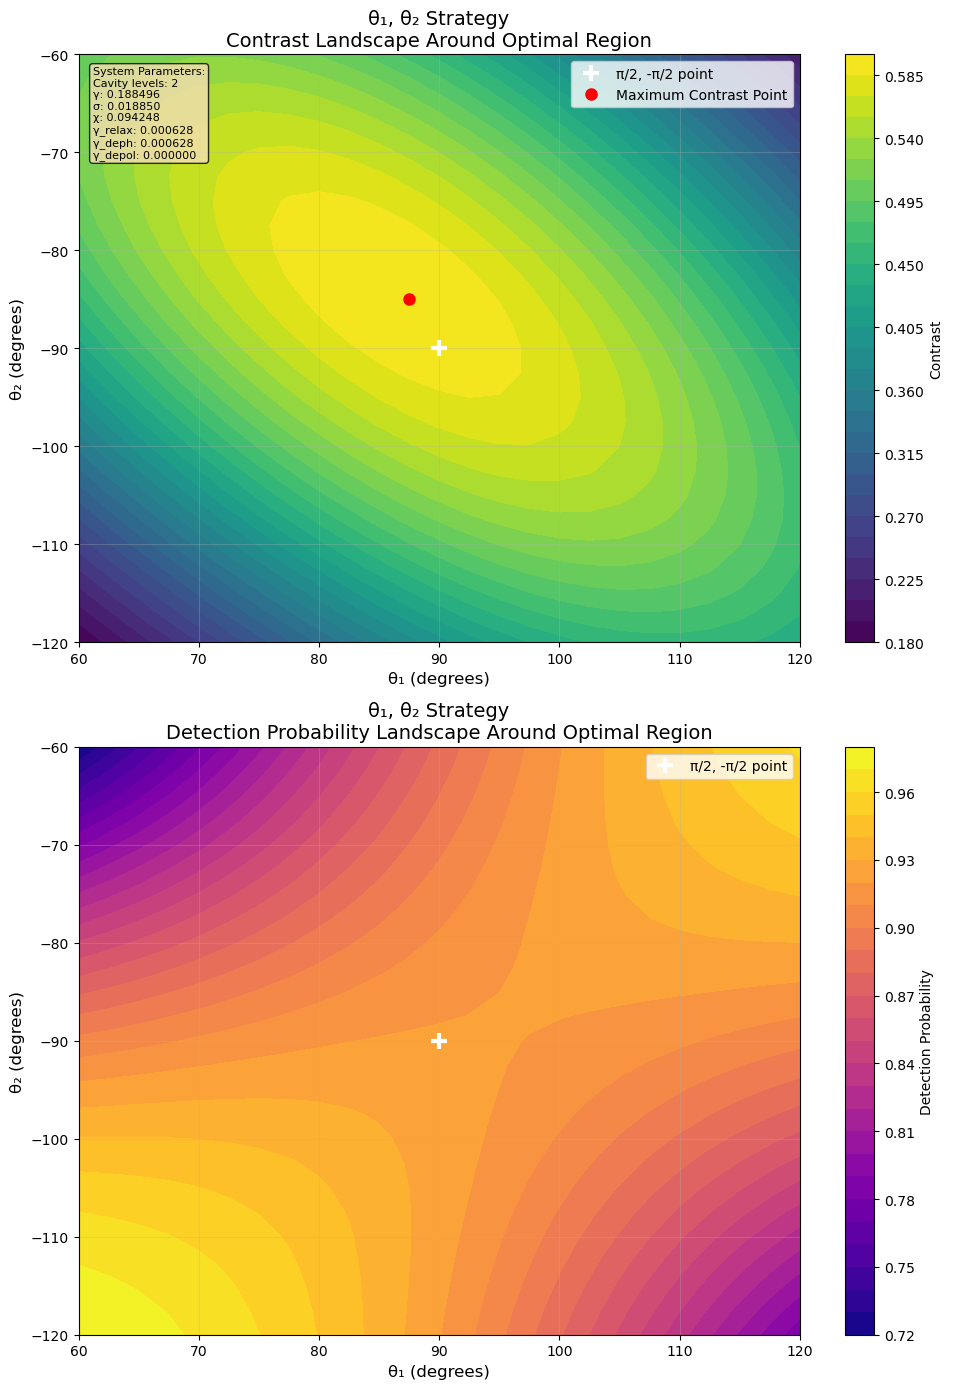


θ₁, θ₂ Region Analysis:
Contrast - Maximum: θ₁=87.50°, θ₂=-85.00°, Contrast=0.59873911
Reference point: θ₁=90.0°, θ₂=-90.0°
Contrast landscape variation: 4.19e-01
Detection landscape variation: 2.59e-01
Equivalent θ, Δθ: θ=1.25°, Δθ=86.25°


In [17]:
# θ₁, θ₂ strategy landscape analysis around optimal region (π/2, -π/2)
print("Computing θ₁, θ₂ landscape around π/2, -π/2 region...")

# Define parameter range around π/2, -π/2
center_theta1 = np.pi/2    # 90 degrees
center_theta2 = -np.pi/2   # -90 degrees
param_range = np.pi/6      # ±30 degrees around center

# Create parameter grid
theta1_range = (center_theta1 - param_range, center_theta1 + param_range)
theta2_range = (center_theta2 - param_range, center_theta2 + param_range)

resolution = 25  # Higher resolution for detailed view
theta1_vals = np.linspace(theta1_range[0], theta1_range[1], resolution)
theta2_vals = np.linspace(theta2_range[0], theta2_range[1], resolution)
P1, P2 = np.meshgrid(theta1_vals, theta2_vals)

# Compute landscape for θ₁, θ₂ strategy (both contrast and detection probability)
Z_contrast = np.zeros_like(P1)
Z_detection = np.zeros_like(P1)
for i in range(resolution):
    for j in range(resolution):
        if (i * resolution + j) % 10 == 0:
            print(f"  Progress: {((i * resolution + j) / (resolution**2) * 100):.1f}%", end='\r')
        contrast, detection_prob = loss_theta1_theta2([P1[i, j], P2[i, j]])
        Z_contrast[i, j] = contrast
        Z_detection[i, j] = detection_prob

print("\n✓ θ₁, θ₂ landscape computed!")

# Create system parameters text for legend
system_params_text = f"""System Parameters:
Cavity levels: {nlev}
γ: {gm:.6f}
σ: {sigma:.6f}
χ: {chi:.6f}
γ_relax: {gamma_relax:.6f}
γ_deph: {gamma_dephasing:.6f}
γ_depol: {gamma_depol:.6f}"""

# Visualize θ₁, θ₂ strategy - both contrast and detection probability
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 14))

# Convert to degrees for visualization
P1_deg = np.degrees(P1)
P2_deg = np.degrees(P2)

# Plot 1: Contrast landscape
im1 = ax1.contourf(P1_deg, P2_deg, Z_contrast, levels=30, cmap='viridis')
ax1.set_xlabel('θ₁ (degrees)', fontsize=12)
ax1.set_ylabel('θ₂ (degrees)', fontsize=12)
ax1.set_title('θ₁, θ₂ Strategy\nContrast Landscape Around Optimal Region', fontsize=14)
ax1.grid(True, alpha=0.3)
plt.colorbar(im1, ax=ax1, label='Contrast')

# Find and mark the maximum in the region for contrast (positive contrast)
max_idx_contrast = np.unravel_index(np.argmax(Z_contrast), Z_contrast.shape)
max_theta1_contrast = P1[max_idx_contrast]
max_theta2_contrast = P2[max_idx_contrast]
max_contrast_value = Z_contrast[max_idx_contrast]

# Mark points on contrast plot
ax1.plot(np.degrees(center_theta1), np.degrees(center_theta2), 
         'w+', markersize=12, markeredgewidth=3, label='π/2, -π/2 point')
ax1.plot(np.degrees(max_theta1_contrast), np.degrees(max_theta2_contrast), 
         'ro', markersize=8, label='Maximum Contrast Point')
ax1.legend(loc='upper right')

# Plot 2: Detection probability landscape
im2 = ax2.contourf(P1_deg, P2_deg, Z_detection, levels=30, cmap='plasma')
ax2.set_xlabel('θ₁ (degrees)', fontsize=12)
ax2.set_ylabel('θ₂ (degrees)', fontsize=12)
ax2.set_title('θ₁, θ₂ Strategy\nDetection Probability Landscape Around Optimal Region', fontsize=14)
ax2.grid(True, alpha=0.3)
plt.colorbar(im2, ax=ax2, label='Detection Probability')

# Mark reference point on detection probability plot (no maximum point)
ax2.plot(np.degrees(center_theta1), np.degrees(center_theta2), 
         'w+', markersize=12, markeredgewidth=3, label='π/2, -π/2 point')
ax2.legend(loc='upper right')

# Add system parameters as text box
ax1.text(0.02, 0.98, system_params_text, transform=ax1.transAxes, fontsize=8,
         verticalalignment='top', bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8))

plt.tight_layout()
plt.savefig('theta1_theta2_landscapes.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"\nθ₁, θ₂ Region Analysis:")
print(f"Contrast - Maximum: θ₁={np.degrees(max_theta1_contrast):.2f}°, θ₂={np.degrees(max_theta2_contrast):.2f}°, Contrast={max_contrast_value:.8f}")
print(f"Reference point: θ₁=90.0°, θ₂=-90.0°")
print(f"Contrast landscape variation: {Z_contrast.max() - Z_contrast.min():.2e}")
print(f"Detection landscape variation: {Z_detection.max() - Z_detection.min():.2e}")

# Compare with equivalent θ, Δθ parameterization
equiv_theta = (max_theta1_contrast + max_theta2_contrast) / 2
equiv_delta = (max_theta1_contrast - max_theta2_contrast) / 2
print(f"Equivalent θ, Δθ: θ={np.degrees(equiv_theta):.2f}°, Δθ={np.degrees(equiv_delta):.2f}°")

Computing θ, Δθ landscape around 0, π/2 region...
  Progress: 99.2%
✓ θ, Δθ landscape computed!

✓ θ, Δθ landscape computed!


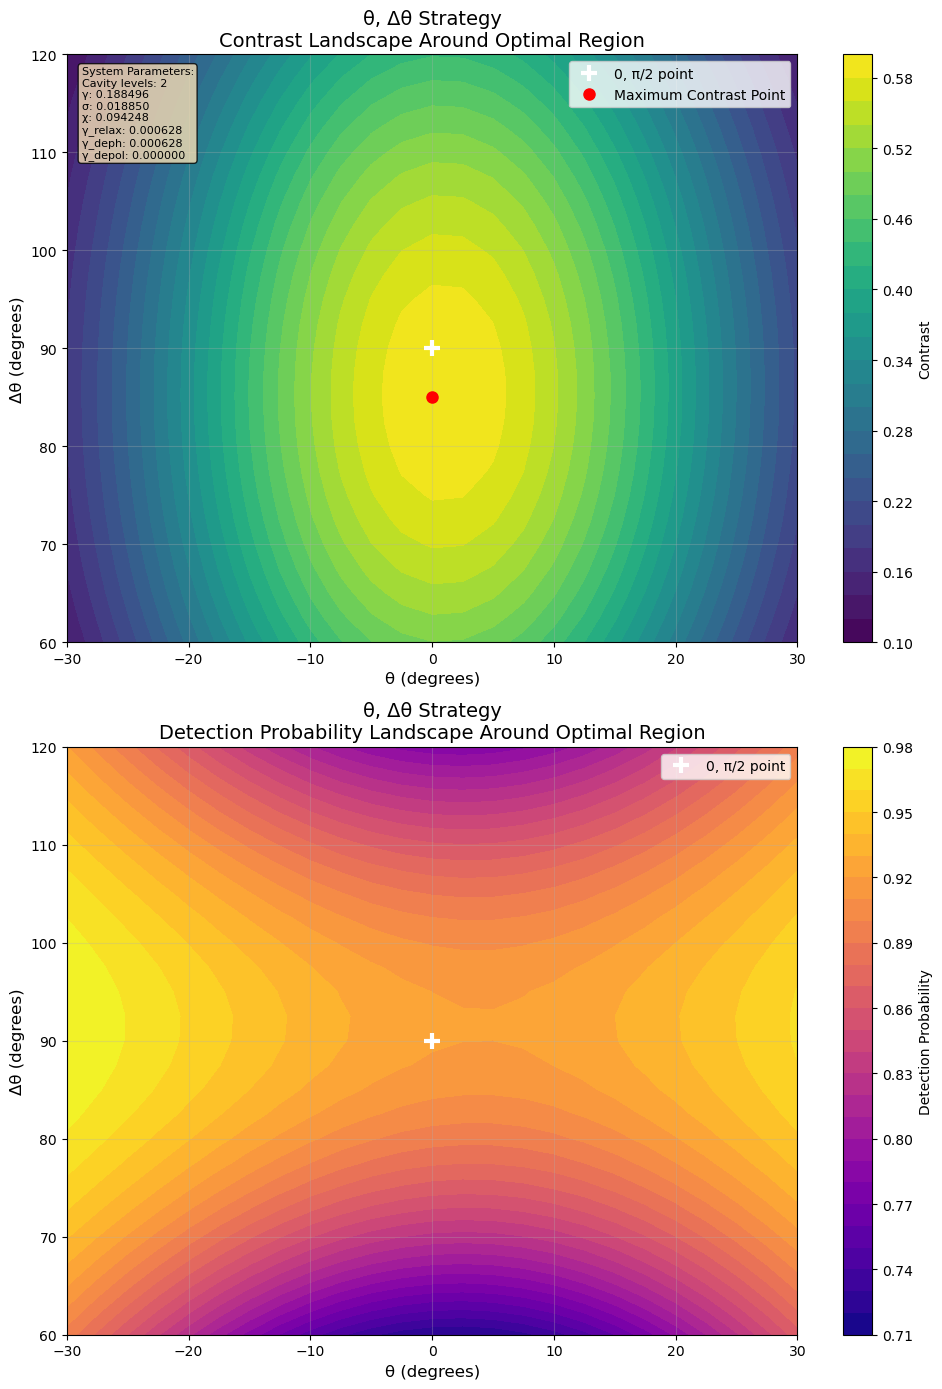


θ, Δθ Region Analysis:
Contrast - Maximum: θ=0.00°, Δθ=85.00°, Contrast=0.59821676
Reference point: θ=0.0°, Δθ=90.0°
Contrast landscape variation: 4.78e-01
Detection landscape variation: 2.60e-01
Equivalent θ₁, θ₂: θ₁=85.00°, θ₂=-85.00°
Verification: θ₁, θ₂ contrast = 0.59821676 (difference: 0.00e+00)


In [18]:
# θ, Δθ strategy landscape analysis around optimal region (0, π/2)
print("Computing θ, Δθ landscape around 0, π/2 region...")

# Define parameter range around 0, π/2
center_theta = 0.0         # 0 degrees
center_delta = np.pi/2     # 90 degrees
range_theta = np.pi/6      # ±30 degrees around theta center
range_delta = np.pi/6      # ±30 degrees around delta center

# Create parameter grid for θ, Δθ
theta_range = (center_theta - range_theta, center_theta + range_theta)
delta_range = (center_delta - range_delta, center_delta + range_delta)

resolution_td = 25  # Higher resolution for detailed view
theta_vals = np.linspace(theta_range[0], theta_range[1], resolution_td)
delta_vals = np.linspace(delta_range[0], delta_range[1], resolution_td)
P_theta, P_delta = np.meshgrid(theta_vals, delta_vals)

# Compute landscape for θ, Δθ strategy (both contrast and detection probability)
Z_td_contrast = np.zeros_like(P_theta)
Z_td_detection = np.zeros_like(P_theta)
for i in range(resolution_td):
    for j in range(resolution_td):
        if (i * resolution_td + j) % 10 == 0:
            print(f"  Progress: {((i * resolution_td + j) / (resolution_td**2) * 100):.1f}%", end='\r')
        contrast, detection_prob = loss_theta_delta([P_theta[i, j], P_delta[i, j]])
        Z_td_contrast[i, j] = contrast
        Z_td_detection[i, j] = detection_prob

print("\n✓ θ, Δθ landscape computed!")

# Visualize θ, Δθ strategy - both contrast and detection probability
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 14))

# Convert to degrees for visualization
P_theta_deg = np.degrees(P_theta)
P_delta_deg = np.degrees(P_delta)

# Plot 1: Contrast landscape
im1 = ax1.contourf(P_theta_deg, P_delta_deg, Z_td_contrast, levels=30, cmap='viridis')
ax1.set_xlabel('θ (degrees)', fontsize=12)
ax1.set_ylabel('Δθ (degrees)', fontsize=12)
ax1.set_title('θ, Δθ Strategy\nContrast Landscape Around Optimal Region', fontsize=14)
ax1.grid(True, alpha=0.3)
plt.colorbar(im1, ax=ax1, label='Contrast')

# Find and mark the maximum in the region for contrast (positive contrast)
max_idx_td_contrast = np.unravel_index(np.argmax(Z_td_contrast), Z_td_contrast.shape)
max_theta_contrast = P_theta[max_idx_td_contrast]
max_delta_contrast = P_delta[max_idx_td_contrast]
max_contrast_td_value = Z_td_contrast[max_idx_td_contrast]

# Mark points on contrast plot
ax1.plot(np.degrees(center_theta), np.degrees(center_delta), 
         'w+', markersize=12, markeredgewidth=3, label='0, π/2 point')
ax1.plot(np.degrees(max_theta_contrast), np.degrees(max_delta_contrast),
         'ro', markersize=8, label='Maximum Contrast Point')
ax1.legend(loc='upper right')

# Plot 2: Detection probability landscape  
im2 = ax2.contourf(P_theta_deg, P_delta_deg, Z_td_detection, levels=30, cmap='plasma')
ax2.set_xlabel('θ (degrees)', fontsize=12)
ax2.set_ylabel('Δθ (degrees)', fontsize=12)
ax2.set_title('θ, Δθ Strategy\nDetection Probability Landscape Around Optimal Region', fontsize=14)
ax2.grid(True, alpha=0.3)
plt.colorbar(im2, ax=ax2, label='Detection Probability')

# Mark reference point on detection probability plot (no maximum point)
ax2.plot(np.degrees(center_theta), np.degrees(center_delta), 
         'w+', markersize=12, markeredgewidth=3, label='0, π/2 point')
ax2.legend(loc='upper right')

# Add system parameters as text box
ax1.text(0.02, 0.98, system_params_text, transform=ax1.transAxes, fontsize=8,
         verticalalignment='top', bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8))

plt.tight_layout()
plt.savefig('theta_delta_landscapes.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"\nθ, Δθ Region Analysis:")
print(f"Contrast - Maximum: θ={np.degrees(max_theta_contrast):.2f}°, Δθ={np.degrees(max_delta_contrast):.2f}°, Contrast={max_contrast_td_value:.8f}")
print(f"Reference point: θ=0.0°, Δθ=90.0°")
print(f"Contrast landscape variation: {Z_td_contrast.max() - Z_td_contrast.min():.2e}")
print(f"Detection landscape variation: {Z_td_detection.max() - Z_td_detection.min():.2e}")

# Compare with equivalent θ₁, θ₂ parameterization
equiv_theta1_td = max_theta_contrast + max_delta_contrast
equiv_theta2_td = max_theta_contrast - max_delta_contrast
print(f"Equivalent θ₁, θ₂: θ₁={np.degrees(equiv_theta1_td):.2f}°, θ₂={np.degrees(equiv_theta2_td):.2f}°")

# Verify equivalence by computing the loss with θ₁, θ₂ parameterization
verify_contrast, verify_detection = loss_theta1_theta2([equiv_theta1_td, equiv_theta2_td])
print(f"Verification: θ₁, θ₂ contrast = {verify_contrast:.8f} (difference: {abs(max_contrast_td_value - verify_contrast):.2e})")